# Module 3 — Notebook 3: Supervised Anomaly Detection Models — FINAL

This notebook trains and evaluates all required supervised anomaly detection models:

- Logistic Regression
- Random Forest
- Extra Trees
- HistGradientBoosting
- XGBoost
- LightGBM
- CatBoost

Workflow:

1. Load the prepared order-level anomaly dataset from Notebook 1.
2. Build a common preprocessing pipeline.
3. Train all supervised models on the train split.
4. Select thresholds using the validation split only.
5. Evaluate on the test split.
6. Save metrics, predictions, figures, feature importances, and model artifacts.

No final module winner is selected here. The final decision will be made in Notebook 4 by comparing supervised and unsupervised results.

In [2]:
import json
import os
import warnings
from pathlib import Path
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    precision_score, recall_score, f1_score, precision_recall_curve,
    average_precision_score, roc_auc_score, confusion_matrix
)
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier

# Required external supervised models.
# Install once if needed:
# pip install xgboost lightgbm catboost
try:
    from xgboost import XGBClassifier
    from lightgbm import LGBMClassifier
    from catboost import CatBoostClassifier
except ImportError as e:
    raise ImportError("Missing package. Run: pip install xgboost lightgbm catboost") from e

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)

SEED = 42
np.random.seed(SEED)

# Main threshold strategy used for the selected leaderboard.
# Other modes are still evaluated and saved.
SELECTED_MODE = 'balanced_f1'

PRECISION_FLOORS = {
    'balanced_f1': 0.60,
    'precision_floor_60': 0.60,
    'precision_floor_65': 0.65,
    'precision_floor_70': 0.70,
}

threshold_modes = ['balanced_f1', 'precision_floor_60', 'precision_floor_65', 'precision_floor_70']

# Output folders: expected notebook location = Notebooks/Module 3/Supervised/
OUTPUT_DIR = Path('../Supervised')
MODEL_DIR = OUTPUT_DIR / 'models'
FIGURE_DIR = OUTPUT_DIR / 'figures'
METRIC_DIR = OUTPUT_DIR / 'metrics'
PREDICTION_DIR = OUTPUT_DIR / 'predictions'
REPORT_DIR = OUTPUT_DIR / 'reports'

for d in [OUTPUT_DIR, MODEL_DIR, FIGURE_DIR, METRIC_DIR, PREDICTION_DIR, REPORT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print('OUTPUT_DIR:', OUTPUT_DIR.resolve())
print('Selected threshold mode:', SELECTED_MODE)

OUTPUT_DIR: C:\Users\slimc\Desktop\Notebooks\Module 3\Supervised
Selected threshold mode: balanced_f1


## 1. Locate and load prepared data

The notebook automatically searches for `order_level_anomaly_dataset.csv` and `anomaly_feature_schema.json` in the expected Module 3 data-preparation locations.

In [3]:
def find_file(filename, candidates):
    for base in candidates:
        p = base / filename
        if p.exists():
            return p
    # fallback: search nearby folders only
    search_roots = [Path('.'), Path('..'), Path('../..')]
    for root in search_roots:
        matches = list(root.rglob(filename))
        if matches:
            return matches[0]
    raise FileNotFoundError(f"Could not find {filename}. Run Notebook 1 first.")

candidate_dirs = [
    Path('../Data Preparation'),
    Path('../Module 3 Data Preparation'),
    Path('../../Module 3 Data Preparation'),
    Path('../Data Preparation/outputs/module3/data'),
    Path('../../Module 3 Data Preparation/outputs/module3/data'),
    Path('../../module3_anomaly_detection/outputs/module3/data'),
]

DATA_PATH = find_file('order_level_anomaly_dataset.csv', candidate_dirs)
SCHEMA_PATH = find_file('anomaly_feature_schema.json', candidate_dirs)

print('DATA_PATH:', DATA_PATH.resolve())
print('SCHEMA_PATH:', SCHEMA_PATH.resolve())

df = pd.read_csv(DATA_PATH)
with open(SCHEMA_PATH, 'r', encoding='utf-8') as f:
    schema = json.load(f)

print('Dataset shape:', df.shape)
print('Anomaly rate:', f"{df['is_anomaly'].mean():.3%}")
print('Splits:')
display(df['split'].value_counts().to_frame('n_orders'))
print('Anomaly types:')
display(df['anomaly_type'].value_counts().to_frame('count'))
display(df.head())

DATA_PATH: C:\Users\slimc\Desktop\Notebooks\Module 3\Data Preparation\order_level_anomaly_dataset.csv
SCHEMA_PATH: C:\Users\slimc\Desktop\Notebooks\Module 3\Data Preparation\anomaly_feature_schema.json
Dataset shape: (63049, 77)
Anomaly rate: 1.761%
Splits:


,n_orders
train,44134
test,9458
val,9457


Anomaly types:


,count
normal,61939
suspicious_discount,240
basket_size_outlier,200
void_after_payment,200
price_tampering,180
odd_hour,170
shift_end_void_cluster,120


,order_id,order_date,order_time,order_datetime,cashier_id,customer_id,payment_method,table_number,restaurant_type,main_category,basket_size,n_unique_items,n_unique_categories,total_amount,avg_line_total,max_line_total,min_line_total,avg_item_price,max_item_price,min_item_price,mean_discount_rate,max_discount_rate,discount_line_count,estimated_discount_amount,is_voided_order,void_line_count,void_reason_exists,mean_price_deviation_pct,max_abs_price_deviation_pct,mean_abs_price_deviation_pct,mean_daily_item_quantity,max_daily_item_quantity,mean_demand_zscore,max_abs_demand_zscore,has_discount_order,discount_line_rate,void_line_rate,avg_amount_per_item,unique_item_ratio,cashier_shift,cashier_flagged,archetype,price_tier,time_preference,day_preference,basket_size_bias,preferred_sections,preferred_categories,expected_visits,actual_visits,customer_visit_gap,customer_visit_ratio,order_hour,order_dayofweek,order_month,is_weekend,is_odd_hour,is_morning,is_lunch,is_dinner,cashier_total_orders,cashier_avg_order_amount,cashier_std_order_amount,cashier_void_rate,cashier_discount_order_rate,cashier_avg_discount_rate,cashier_amount_zscore,customer_total_orders,customer_avg_order_amount,customer_std_order_amount,customer_avg_basket_size,customer_amount_zscore,customer_basket_deviation,anomaly_type,anomaly_description,is_anomaly,split
0,100009,2023-01-01,07:00 AM,2023-01-01 07:00:00,C01,453,cash,21.0,Cafe,Bakery,2,2,2,8.75,4.375,4.50,4.25,4.375,4.50,4.25,0.0,0.0,0,0.0,False,0,0,0.0,0.0,0.0,6.000000,6,3.761034,3.761789,0,0.0,0.0,4.375,1.0,morning,0,regular,mid,morning,weekend,medium,Cafe,"Dessert,Side,Main",26.0,17.0,-9.0,0.653846,7,6,1,1,0,1,0,0,4647,16.969722,9.960514,0.015924,0.116634,0.016107,-0.825231,17,18.735294,11.586789,3.058824,-0.861783,-1.058824,normal,NaN,0,train
1,100000,2023-01-01,07:30 AM,2023-01-01 07:30:00,C02,520,card,12.0,Cafe,Food,3,3,2,16.50,5.500,6.50,4.50,5.500,6.50,4.50,0.0,0.0,0,0.0,False,0,0,0.0,0.0,0.0,3.666667,5,1.081431,1.283424,0,0.0,0.0,5.500,1.0,morning,0,regular,budget,lunch,any,large,Healthy_Vegan,"Beverage,Side",18.0,14.0,-4.0,0.777778,7,6,1,1,0,1,0,0,4776,16.560787,10.761836,0.014866,0.104481,0.014594,-0.005648,14,26.796429,11.180829,3.928571,-0.920900,-0.928571,normal,NaN,0,train
2,100005,2023-01-01,07:30 AM,2023-01-01 07:30:00,C01,4471,cash,NaN,Cafe,Beverage,2,2,1,9.75,4.875,5.25,4.50,4.875,5.25,4.50,0.0,0.0,0,0.0,False,0,0,0.0,0.0,0.0,4.000000,4,1.644387,2.071410,0,0.0,0.0,4.875,1.0,morning,0,occasional,budget,morning,weekday,small,Cafe,"Beverage,Main",5.0,5.0,0.0,1.000000,7,6,1,1,0,1,0,0,4647,16.969722,9.960514,0.015924,0.116634,0.016107,-0.724834,5,9.670000,1.922108,2.200000,0.041621,-0.200000,normal,NaN,0,train
3,100012,2023-01-01,07:30 AM,2023-01-01 07:30:00,C02,4488,cash,16.0,Cafe,Beverage,4,4,2,17.50,4.375,6.50,2.50,4.375,6.50,2.50,0.0,0.0,0,0.0,False,0,0,0.0,0.0,0.0,3.500000,5,0.904188,2.387091,0,0.0,0.0,4.375,1.0,morning,0,occasional,mid,morning,weekend,medium,Cafe,"Side,Food",9.0,8.0,-1.0,0.888889,7,6,1,1,0,1,0,0,4776,16.560787,10.761836,0.014866,0.104481,0.014594,0.087273,8,15.312500,6.441703,3.125000,0.339584,0.875000,normal,NaN,0,train
4,100001,2023-01-01,08:00 AM,2023-01-01 08:00:00,C03,6381,cash,21.0,Cafe,Bakery,2,2,1,8.75,4.375,4.50,4.25,4.375,4.50,4.25,0.0,0.0,0,0.0,False,0,0,0.0,0.0,0.0,4.500000,6,2.231514,3.761789,0,0.0,0.0,4.375,1.0,morning,0,infrequent,mid,morning,any,small,Cafe,"Alcohol,Main,Dessert",4.0,4.0,0.0,1.000000,8,6,1,1,0,1,0,0,4615,16.907545,13.310245,0.015385,0.112026,0.016407,-0.612877,4,15.687500,13.212013,2.250000,-0.525090,-0.250000,normal,NaN,0,train


## 2. Define supervised features and preprocessing

The same prepared feature schema is used for every supervised model so the comparison is fair.

Preprocessing:

- numeric and binary features: median imputation + standardization,
- categorical features: most frequent imputation + one-hot encoding.

In [4]:
numeric_features = [c for c in schema.get('numeric_features', []) if c in df.columns]
binary_features = [c for c in schema.get('binary_features', []) if c in df.columns]
categorical_features = [c for c in schema.get('categorical_features', []) if c in df.columns]

exclude = {
    'order_id', 'customer_id', 'is_anomaly', 'anomaly_type', 'split',
    'order_date', 'order_time', 'order_datetime'
}

numeric_features = [c for c in numeric_features if c not in exclude]
binary_features = [c for c in binary_features if c not in exclude]
categorical_features = [c for c in categorical_features if c not in exclude]

model_features = numeric_features + binary_features + categorical_features

print('Numeric features:', len(numeric_features))
print('Binary features:', len(binary_features))
print('Categorical features:', len(categorical_features))
print('Total model features:', len(model_features))
print('Categorical features:', categorical_features)

train_df = df[df['split'].eq('train')].copy()
val_df = df[df['split'].eq('val')].copy()
test_df = df[df['split'].eq('test')].copy()

X_train_raw = train_df[model_features]
X_val_raw = val_df[model_features]
X_test_raw = test_df[model_features]

y_train = train_df['is_anomaly'].astype(int).values
y_val = val_df['is_anomaly'].astype(int).values
y_test = test_df['is_anomaly'].astype(int).values

def make_onehot_encoder():
    try:
        return OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown='ignore', sparse=False)

numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', make_onehot_encoder())
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numeric_features + binary_features),
    ('cat', categorical_pipeline, categorical_features)
])

X_train = preprocessor.fit_transform(X_train_raw)
X_val = preprocessor.transform(X_val_raw)
X_test = preprocessor.transform(X_test_raw)

sample_weight_train = compute_sample_weight(class_weight='balanced', y=y_train)
n_pos = int(y_train.sum())
n_neg = int(len(y_train) - n_pos)
scale_pos_weight = n_neg / max(n_pos, 1)

print('Train matrix:', X_train.shape)
print('Validation matrix:', X_val.shape)
print('Test matrix:', X_test.shape)
print('Train anomalies:', int(y_train.sum()))
print('Validation anomalies:', int(y_val.sum()))
print('Test anomalies:', int(y_test.sum()))
print('scale_pos_weight:', round(scale_pos_weight, 2))

Numeric features: 47
Binary features: 9
Categorical features: 9
Total model features: 65
Categorical features: ['payment_method', 'restaurant_type', 'main_category', 'cashier_shift', 'archetype', 'price_tier', 'time_preference', 'day_preference', 'basket_size_bias']
Train matrix: (44134, 94)
Validation matrix: (9457, 94)
Test matrix: (9458, 94)
Train anomalies: 756
Validation anomalies: 178
Test anomalies: 176
scale_pos_weight: 57.38


## 3. Metrics and threshold helpers

Each classifier outputs a probability score. Thresholds are selected on the validation set, then applied once to the test set.

In [5]:
def build_threshold_curve(y_true, scores):
    precision, recall, thresholds = precision_recall_curve(y_true, scores)
    rows = []
    for i, threshold in enumerate(thresholds):
        p = precision[i]
        r = recall[i]
        f1 = 2 * p * r / (p + r + 1e-12)
        rows.append({'threshold': float(threshold), 'precision': float(p), 'recall': float(r), 'f1': float(f1)})
    return pd.DataFrame(rows)


def choose_threshold(curve_df, mode='balanced_f1', precision_floor=0.60):
    if curve_df.empty:
        return 0.5
    if mode == 'balanced_f1':
        return float(curve_df.loc[curve_df['f1'].idxmax(), 'threshold'])
    if mode.startswith('precision_floor'):
        candidates = curve_df[curve_df['precision'] >= precision_floor].copy()
        if candidates.empty:
            return float(curve_df.loc[curve_df['f1'].idxmax(), 'threshold'])
        candidates = candidates.sort_values(['recall', 'f1'], ascending=[False, False])
        return float(candidates.iloc[0]['threshold'])
    return float(curve_df.loc[curve_df['f1'].idxmax(), 'threshold'])


def top_k_metrics(y_true, scores, k):
    y_true = np.asarray(y_true)
    scores = np.asarray(scores)
    order = np.argsort(scores)[::-1]
    top_idx = order[:min(k, len(order))]
    found = int(y_true[top_idx].sum())
    return found / max(len(top_idx), 1), found / max(int(y_true.sum()), 1), found


def evaluate_predictions(model_name, split_name, y_true, scores, threshold, threshold_mode):
    pred = (scores >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()
    p50, r50, found50 = top_k_metrics(y_true, scores, 50)
    p100, r100, found100 = top_k_metrics(y_true, scores, 100)
    p200, r200, found200 = top_k_metrics(y_true, scores, 200)
    try:
        roc = roc_auc_score(y_true, scores)
    except Exception:
        roc = np.nan
    return {
        'model': model_name,
        'split': split_name,
        'threshold_mode': threshold_mode,
        'threshold': float(threshold),
        'precision': precision_score(y_true, pred, zero_division=0),
        'recall': recall_score(y_true, pred, zero_division=0),
        'f1': f1_score(y_true, pred, zero_division=0),
        'pr_auc': average_precision_score(y_true, scores),
        'roc_auc': roc,
        'tn': int(tn), 'fp': int(fp), 'fn': int(fn), 'tp': int(tp),
        'false_alerts': int(fp),
        'missed_anomalies': int(fn),
        'alert_count': int(pred.sum()),
        'alert_rate': float(pred.mean()),
        'precision_at_50': p50, 'recall_at_50': r50, 'anomalies_found_at_50': found50,
        'precision_at_100': p100, 'recall_at_100': r100, 'anomalies_found_at_100': found100,
        'precision_at_200': p200, 'recall_at_200': r200, 'anomalies_found_at_200': found200,
    }


def normalize_scores(scores):
    scores = np.asarray(scores, dtype=float)
    mn, mx = np.nanmin(scores), np.nanmax(scores)
    if mx - mn < 1e-12:
        return np.zeros_like(scores)
    return (scores - mn) / (mx - mn)

## 4. Define all supervised models

In [6]:
models = {
    'Logistic Regression': LogisticRegression(
        class_weight='balanced', max_iter=3000, solver='lbfgs', random_state=SEED
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=400, max_depth=None, min_samples_leaf=2,
        class_weight='balanced_subsample', n_jobs=-1, random_state=SEED
    ),
    'Extra Trees': ExtraTreesClassifier(
        n_estimators=400, max_depth=None, min_samples_leaf=2,
        class_weight='balanced', n_jobs=-1, random_state=SEED
    ),
    'HistGradientBoosting': HistGradientBoostingClassifier(
        learning_rate=0.05, max_iter=400, max_leaf_nodes=31,
        l2_regularization=0.05, random_state=SEED
    ),
    'XGBoost': XGBClassifier(
        n_estimators=500, max_depth=4, learning_rate=0.04,
        subsample=0.90, colsample_bytree=0.90, eval_metric='logloss',
        scale_pos_weight=scale_pos_weight, tree_method='hist',
        random_state=SEED, n_jobs=-1
    ),
    'LightGBM': LGBMClassifier(
        n_estimators=550, learning_rate=0.04, num_leaves=31,
        subsample=0.90, colsample_bytree=0.90, class_weight='balanced',
        random_state=SEED, n_jobs=-1, verbose=-1
    ),
    'CatBoost': CatBoostClassifier(
        iterations=550, depth=6, learning_rate=0.04,
        loss_function='Logloss', eval_metric='F1',
        class_weights=[1.0, scale_pos_weight],
        random_seed=SEED, verbose=False
    ),
}

REQUIRED_MODELS = list(models.keys())
print('Models to train:')
for m in REQUIRED_MODELS:
    print(' -', m)

Models to train:
 - Logistic Regression
 - Random Forest
 - Extra Trees
 - HistGradientBoosting
 - XGBoost
 - LightGBM
 - CatBoost


## 5. Train models and evaluate validation-selected thresholds

In [7]:
trained_models = {}
scores_val = {}
scores_test = {}
curves = {}
all_metrics = []
selected_metrics = []

for name, model in models.items():
    print('\nTraining:', name)

    if name == 'HistGradientBoosting':
        model.fit(X_train, y_train, sample_weight=sample_weight_train)
    else:
        model.fit(X_train, y_train)

    trained_models[name] = model

    if hasattr(model, 'predict_proba'):
        val_score = model.predict_proba(X_val)[:, 1]
        test_score = model.predict_proba(X_test)[:, 1]
    else:
        val_score = normalize_scores(model.decision_function(X_val))
        test_score = normalize_scores(model.decision_function(X_test))

    scores_val[name] = val_score
    scores_test[name] = test_score
    curve = build_threshold_curve(y_val, val_score)
    curves[name] = curve

    for mode in threshold_modes:
        threshold = choose_threshold(curve, mode=mode, precision_floor=PRECISION_FLOORS.get(mode, 0.60))
        all_metrics.append(evaluate_predictions(name, 'val', y_val, val_score, threshold, mode))
        test_metrics = evaluate_predictions(name, 'test', y_test, test_score, threshold, mode)
        all_metrics.append(test_metrics)
        if mode == SELECTED_MODE:
            selected_metrics.append(test_metrics)

    selected_threshold = choose_threshold(curve, mode=SELECTED_MODE, precision_floor=PRECISION_FLOORS.get(SELECTED_MODE, 0.60))
    selected_test = evaluate_predictions(name, 'test', y_test, test_score, selected_threshold, SELECTED_MODE)
    print(
        f"{name}: threshold={selected_threshold:.4f} | "
        f"test P/R/F1={selected_test['precision']:.3f}/{selected_test['recall']:.3f}/{selected_test['f1']:.3f}"
    )

missing = sorted(set(REQUIRED_MODELS) - set(trained_models))
assert not missing, f"Missing trained models: {missing}"
print('\nAll required supervised models trained successfully.')


Training: Logistic Regression
Logistic Regression: threshold=0.9791 | test P/R/F1=0.958/0.903/0.930

Training: Random Forest
Random Forest: threshold=0.2545 | test P/R/F1=0.965/0.938/0.951

Training: Extra Trees
Extra Trees: threshold=0.3830 | test P/R/F1=0.965/0.932/0.948

Training: HistGradientBoosting
HistGradientBoosting: threshold=0.9155 | test P/R/F1=0.976/0.920/0.947

Training: XGBoost
XGBoost: threshold=0.9601 | test P/R/F1=0.994/0.903/0.946

Training: LightGBM
LightGBM: threshold=0.1277 | test P/R/F1=0.964/0.915/0.939

Training: CatBoost
CatBoost: threshold=0.7323 | test P/R/F1=0.953/0.932/0.943

All required supervised models trained successfully.


## 6. Supervised metrics leaderboard

In [8]:
metrics_all_df = pd.DataFrame(all_metrics)
metrics_selected_df = pd.DataFrame(selected_metrics).sort_values('f1', ascending=False).reset_index(drop=True)

metrics_all_path = METRIC_DIR / 'supervised_metrics_all_threshold_modes.csv'
metrics_selected_path = METRIC_DIR / 'supervised_metrics.csv'
metrics_all_df.to_csv(metrics_all_path, index=False)
metrics_selected_df.to_csv(metrics_selected_path, index=False)

print('Saved all modes to:', metrics_all_path)
print('Saved selected-mode test metrics to:', metrics_selected_path)
print('Selected mode:', SELECTED_MODE)

display(metrics_selected_df[[
    'model', 'precision', 'recall', 'f1', 'pr_auc', 'roc_auc',
    'false_alerts', 'missed_anomalies', 'alert_count', 'alert_rate',
    'precision_at_50', 'recall_at_50',
    'precision_at_100', 'recall_at_100',
    'precision_at_200', 'recall_at_200'
]])

Saved all modes to: ..\Supervised\metrics\supervised_metrics_all_threshold_modes.csv
Saved selected-mode test metrics to: ..\Supervised\metrics\supervised_metrics.csv
Selected mode: balanced_f1


,model,precision,recall,f1,pr_auc,roc_auc,false_alerts,missed_anomalies,alert_count,alert_rate,precision_at_50,recall_at_50,precision_at_100,recall_at_100,precision_at_200,recall_at_200
0,Random Forest,0.964912,0.937500,0.951009,0.976973,0.999372,6,11,171,0.018080,1.0,0.284091,1.0,0.568182,0.830,0.943182
1,Extra Trees,0.964706,0.931818,0.947977,0.979500,0.999505,6,12,170,0.017974,1.0,0.284091,1.0,0.568182,0.840,0.954545
2,HistGradientBoosting,0.975904,0.920455,0.947368,0.975152,0.999268,4,14,166,0.017551,1.0,0.284091,1.0,0.568182,0.825,0.937500
3,XGBoost,0.993750,0.903409,0.946429,0.978580,0.999382,1,17,160,0.016917,1.0,0.284091,1.0,0.568182,0.830,0.943182
4,CatBoost,0.953488,0.931818,0.942529,0.978288,0.999371,8,12,172,0.018186,1.0,0.284091,1.0,0.568182,0.840,0.954545
5,LightGBM,0.964072,0.914773,0.938776,0.979092,0.999451,6,15,167,0.017657,1.0,0.284091,1.0,0.568182,0.835,0.948864
6,Logistic Regression,0.957831,0.903409,0.929825,0.973235,0.999275,7,17,166,0.017551,1.0,0.284091,1.0,0.568182,0.830,0.943182


## 7. Threshold strategy comparison

In [9]:
threshold_comparison = (
    metrics_all_df[metrics_all_df['split'].eq('test')]
    .sort_values(['model', 'threshold_mode'])
    [[
        'model', 'threshold_mode', 'precision', 'recall', 'f1',
        'false_alerts', 'missed_anomalies', 'alert_count', 'alert_rate'
    ]]
)

display(threshold_comparison)
threshold_comparison.to_csv(METRIC_DIR / 'supervised_threshold_strategy_comparison.csv', index=False)

,model,threshold_mode,precision,recall,f1,false_alerts,missed_anomalies,alert_count,alert_rate
49,CatBoost,balanced_f1,0.953488,0.931818,0.942529,8,12,172,0.018186
51,CatBoost,precision_floor_60,0.645038,0.960227,0.771689,93,7,262,0.027701
53,CatBoost,precision_floor_65,0.670635,0.960227,0.789720,83,7,252,0.026644
55,CatBoost,precision_floor_70,0.781395,0.954545,0.859335,47,8,215,0.022732
17,Extra Trees,balanced_f1,0.964706,0.931818,0.947977,6,12,170,0.017974
19,Extra Trees,precision_floor_60,0.662879,0.994318,0.795455,89,1,264,0.027913
21,Extra Trees,precision_floor_65,0.662879,0.994318,0.795455,89,1,264,0.027913
23,Extra Trees,precision_floor_70,0.887701,0.943182,0.914601,21,10,187,0.019772
25,HistGradientBoosting,balanced_f1,0.975904,0.920455,0.947368,4,14,166,0.017551
27,HistGradientBoosting,precision_floor_60,0.621818,0.971591,0.758315,104,5,275,0.029076


## 8. Visual model comparison

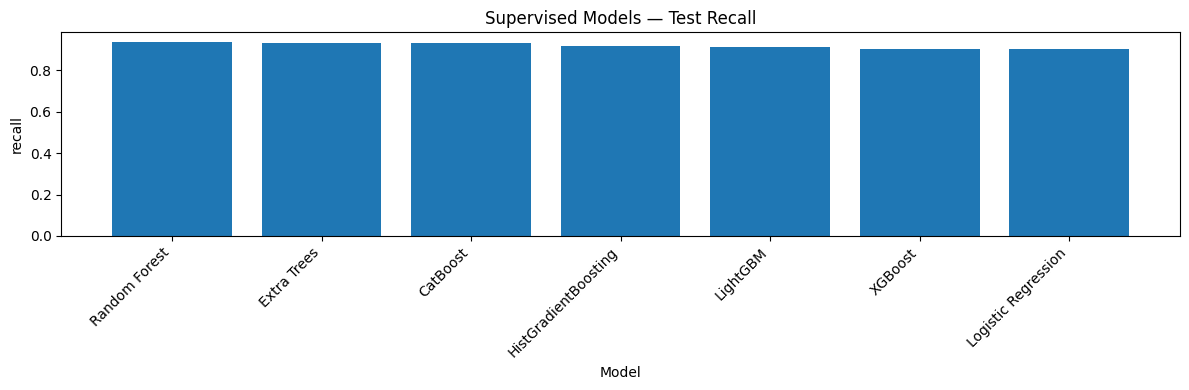

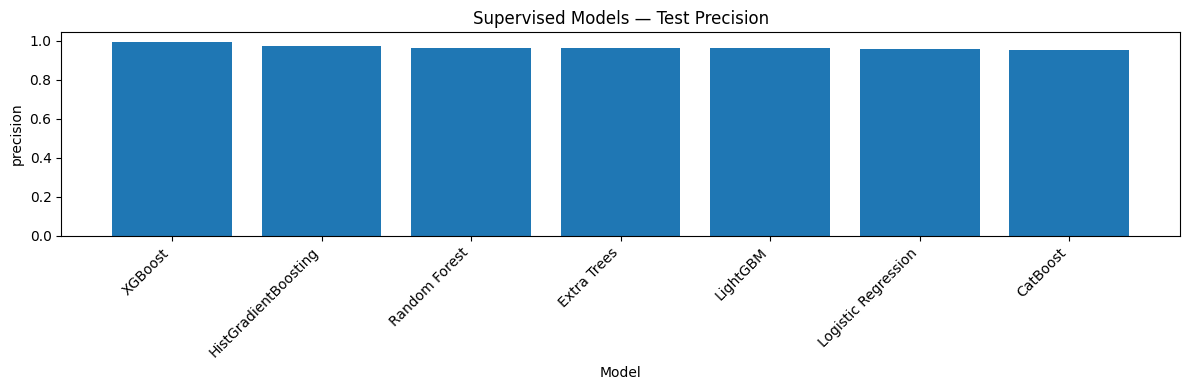

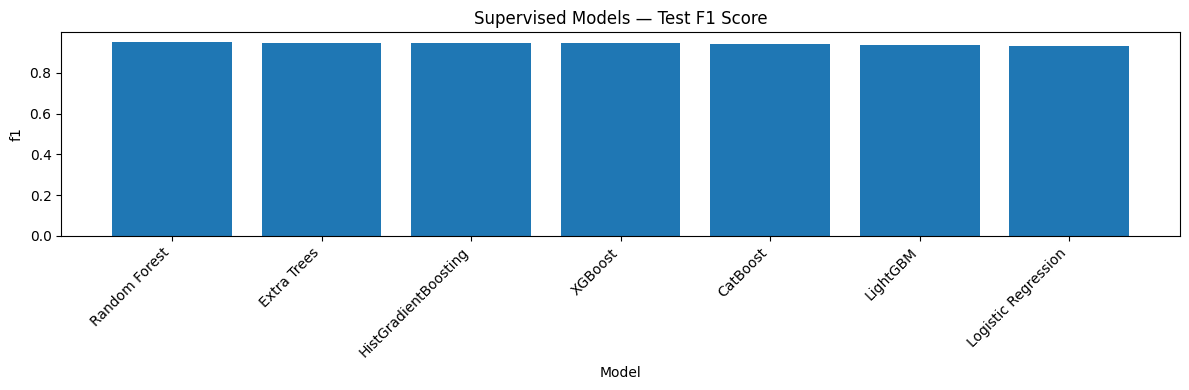

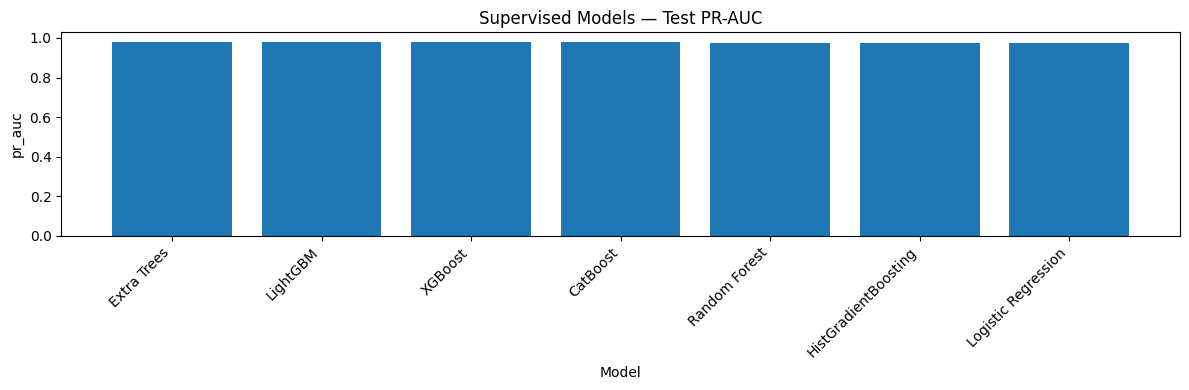

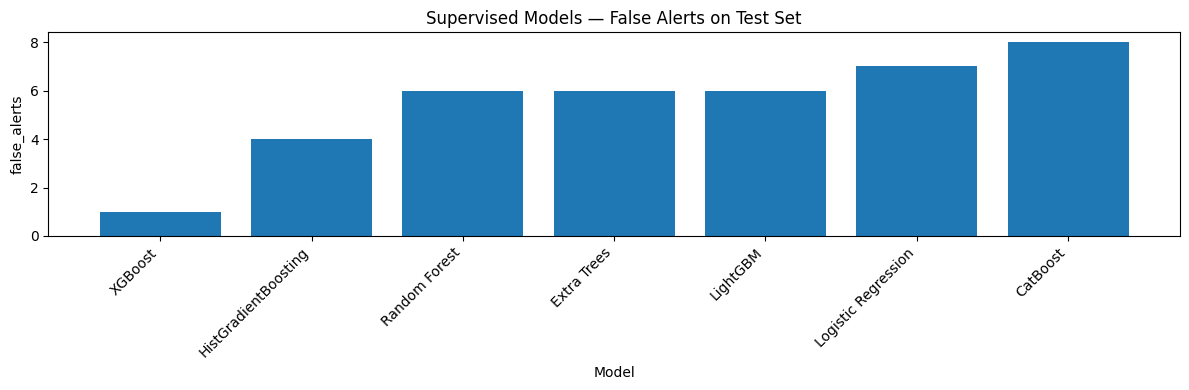

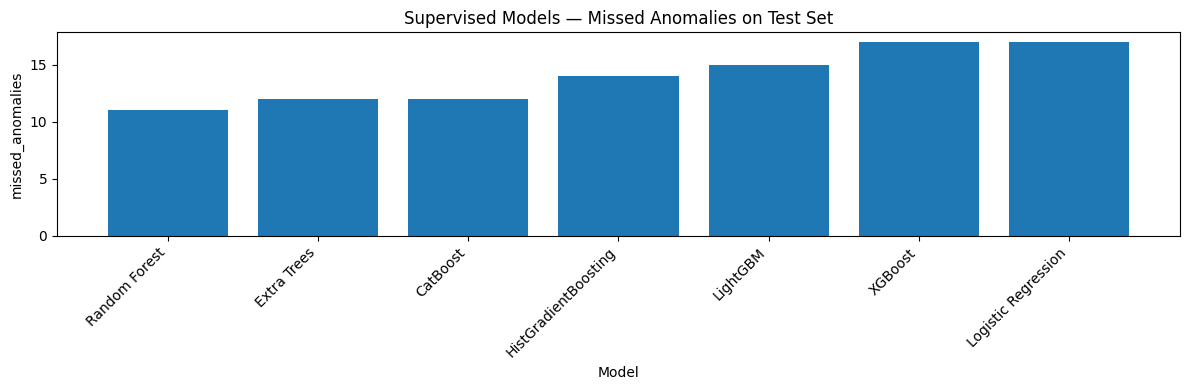

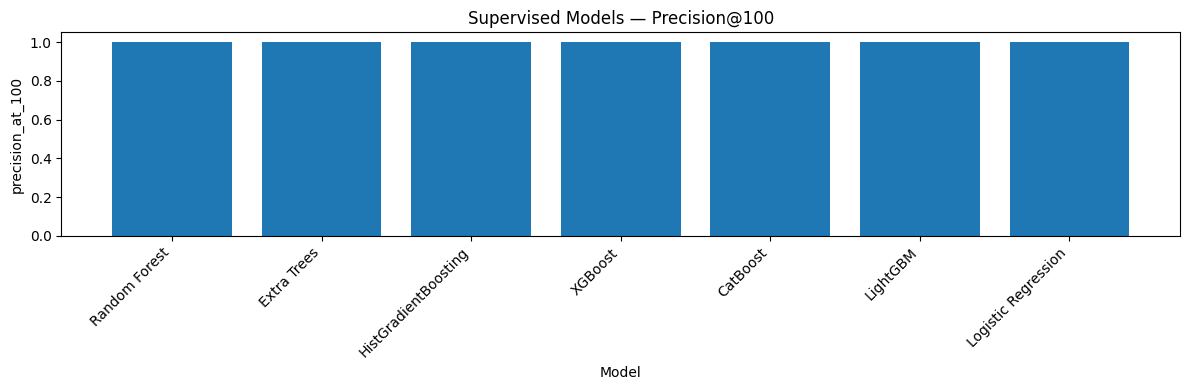

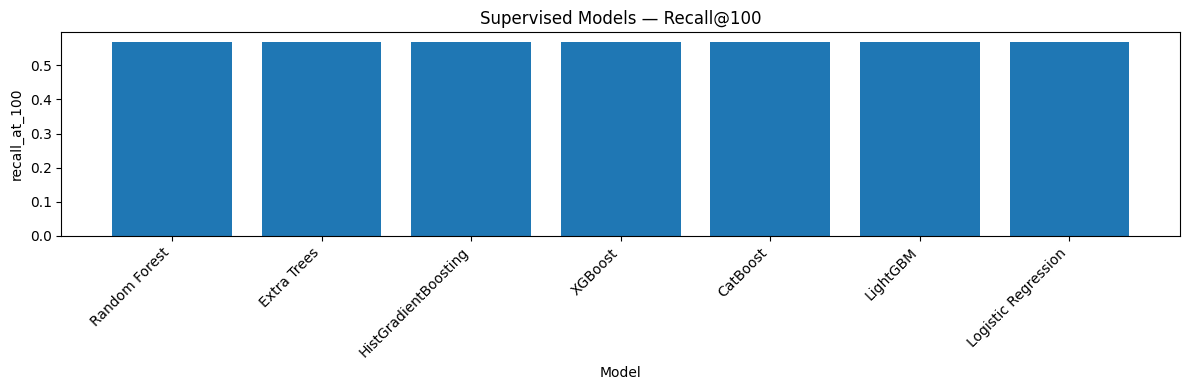

In [10]:
def plot_metric_bar(metrics_df, metric, title, ascending=False):
    plot_df = metrics_df.sort_values(metric, ascending=ascending)
    plt.figure(figsize=(12, 4))
    plt.bar(plot_df['model'], plot_df[metric])
    plt.title(title)
    plt.ylabel(metric)
    plt.xlabel('Model')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    path = FIGURE_DIR / f"supervised_{metric}.png"
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()

for metric, title, asc in [
    ('recall', 'Supervised Models — Test Recall', False),
    ('precision', 'Supervised Models — Test Precision', False),
    ('f1', 'Supervised Models — Test F1 Score', False),
    ('pr_auc', 'Supervised Models — Test PR-AUC', False),
    ('false_alerts', 'Supervised Models — False Alerts on Test Set', True),
    ('missed_anomalies', 'Supervised Models — Missed Anomalies on Test Set', True),
    ('precision_at_100', 'Supervised Models — Precision@100', False),
    ('recall_at_100', 'Supervised Models — Recall@100', False),
]:
    plot_metric_bar(metrics_selected_df, metric, title, ascending=asc)

## 9. Precision-Recall curves

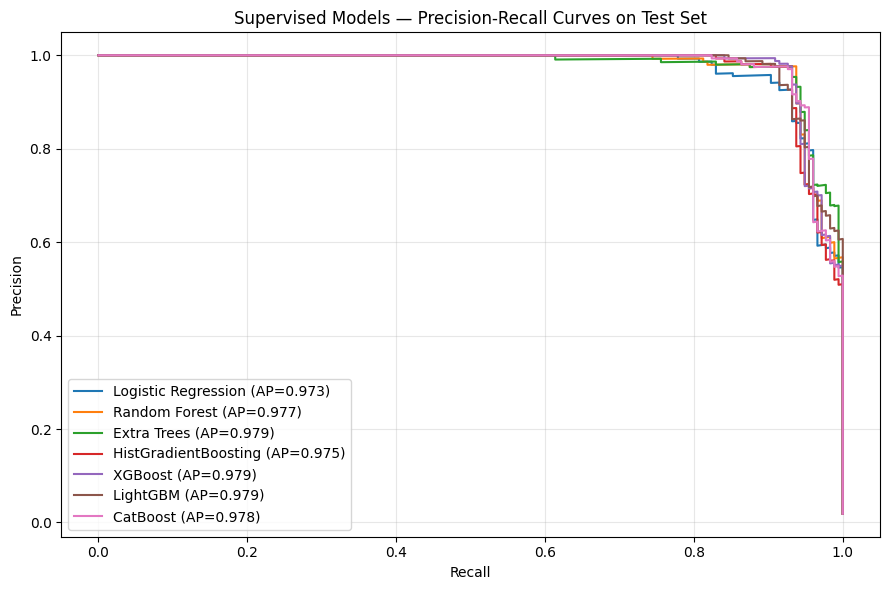

In [11]:
plt.figure(figsize=(9, 6))
for name, score in scores_test.items():
    precision, recall, _ = precision_recall_curve(y_test, score)
    ap = average_precision_score(y_test, score)
    plt.plot(recall, precision, label=f"{name} (AP={ap:.3f})")
plt.title('Supervised Models — Precision-Recall Curves on Test Set')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
path = FIGURE_DIR / 'supervised_precision_recall_curves.png'
plt.savefig(path, dpi=150, bbox_inches='tight')
plt.show()

## 10. Per-model diagnostics: confusion matrix, score distribution, threshold analysis, and top alerts

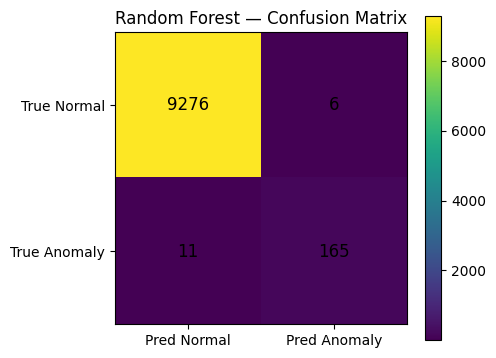

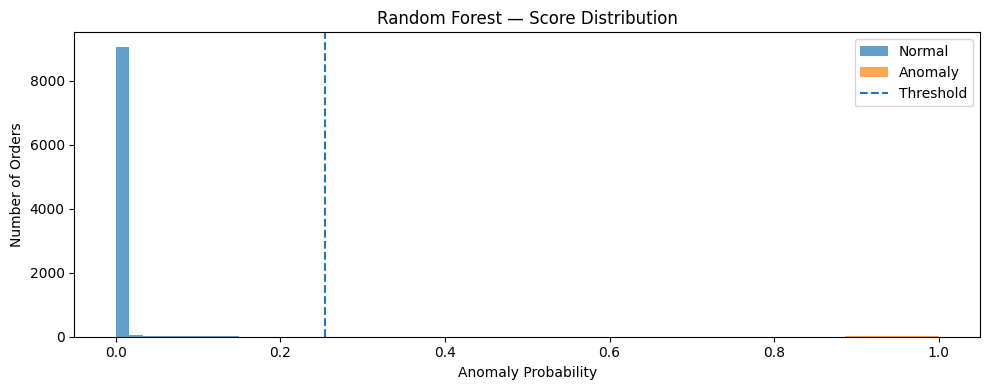

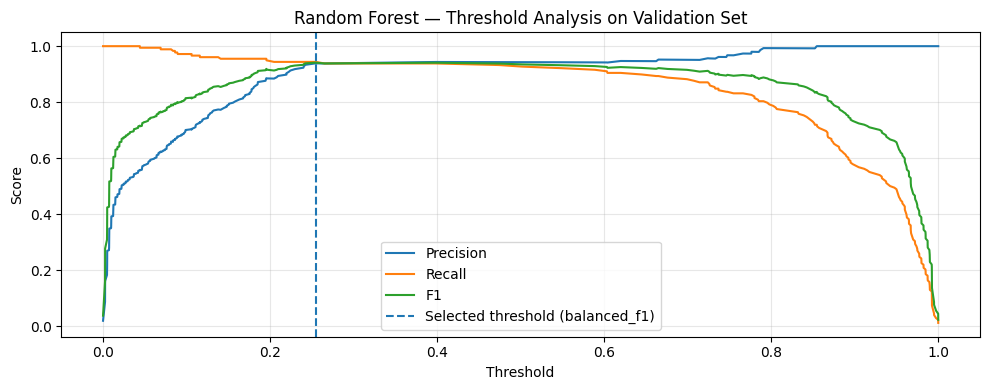

Top alerts for: Random Forest


,order_id,is_anomaly,anomaly_type,cashier_id,total_amount,anomaly_score,predicted_is_anomaly
61516,162985,1,basket_size_outlier,C01,130.50,1.000000,1
56801,156712,1,basket_size_outlier,C03,77.01,1.000000,1
56543,163029,1,basket_size_outlier,C11,127.00,1.000000,1
54232,162982,1,basket_size_outlier,C02,149.50,1.000000,1
59435,159341,1,basket_size_outlier,C05,249.50,0.997500,1
61623,161539,1,suspicious_discount,C07,1.22,0.997359,1
57923,163043,1,basket_size_outlier,C06,155.00,0.997295,1
59583,162962,1,basket_size_outlier,C08,108.00,0.997217,1
60056,159966,1,basket_size_outlier,C03,66.96,0.995000,1
56766,156662,1,basket_size_outlier,C09,104.78,0.995000,1


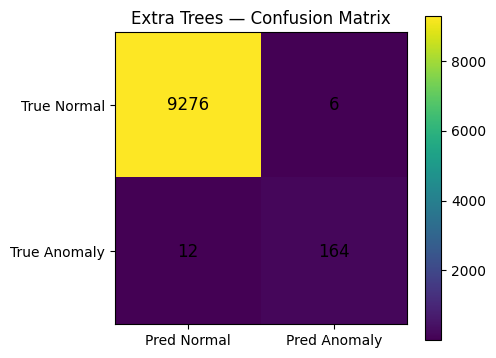

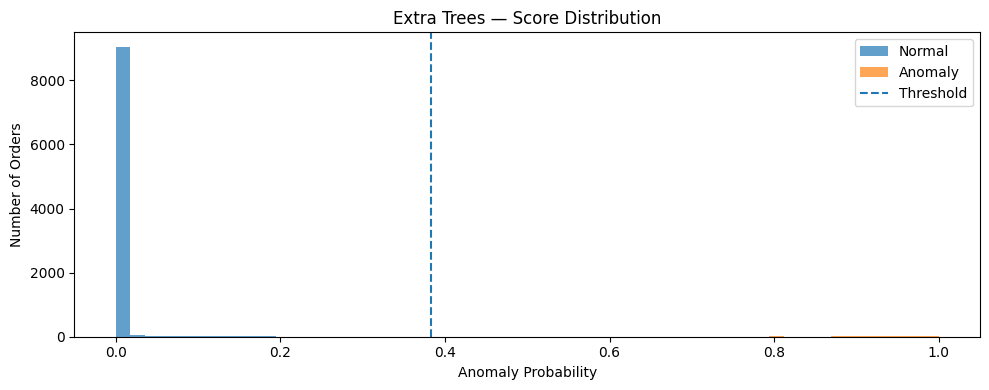

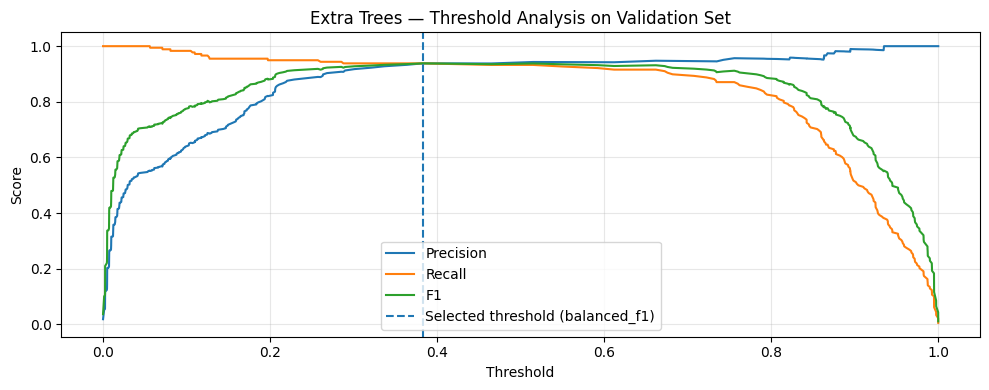

Top alerts for: Extra Trees


,order_id,is_anomaly,anomaly_type,cashier_id,total_amount,anomaly_score,predicted_is_anomaly
56543,163029,1,basket_size_outlier,C11,127.00,1.000000,1
58081,162994,1,basket_size_outlier,C09,93.00,0.999995,1
57923,163043,1,basket_size_outlier,C06,155.00,0.999978,1
56328,162991,1,basket_size_outlier,C09,108.00,0.999936,1
54232,162982,1,basket_size_outlier,C02,149.50,0.999921,1
56801,156712,1,basket_size_outlier,C03,77.01,0.997500,1
62141,163021,1,basket_size_outlier,C11,83.50,0.997495,1
54725,154628,1,basket_size_outlier,C10,138.44,0.995000,1
61820,163003,1,basket_size_outlier,C11,90.00,0.994995,1
61623,161539,1,suspicious_discount,C07,1.22,0.994911,1


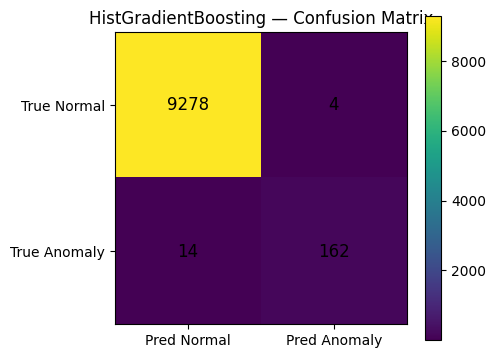

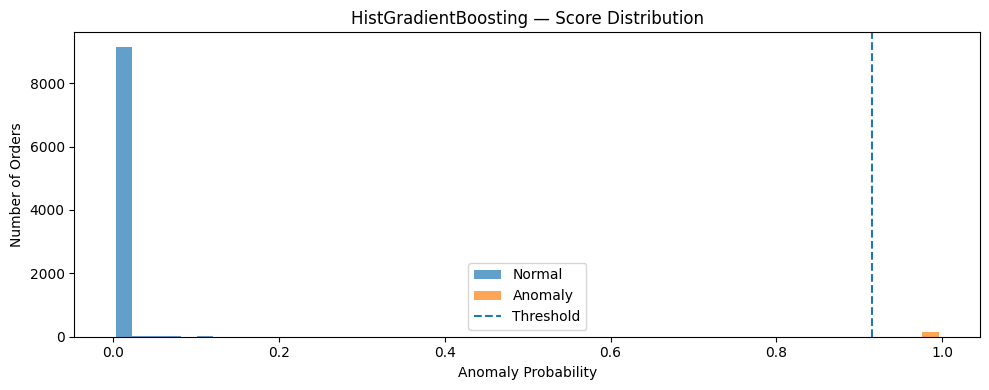

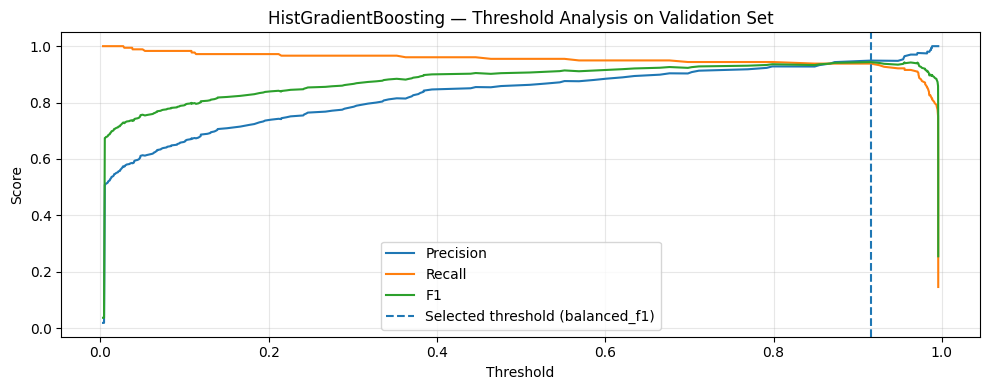

Top alerts for: HistGradientBoosting


,order_id,is_anomaly,anomaly_type,cashier_id,total_amount,anomaly_score,predicted_is_anomaly
57054,156988,1,suspicious_discount,C08,0.95,0.995739,1
62183,162099,1,suspicious_discount,C11,5.30,0.995739,1
57605,157522,1,suspicious_discount,C01,8.40,0.995739,1
53732,153651,1,suspicious_discount,C12,4.05,0.995739,1
62315,162217,1,suspicious_discount,C01,2.20,0.995739,1
54328,154242,1,suspicious_discount,C07,10.24,0.995739,1
61623,161539,1,suspicious_discount,C07,1.22,0.995739,1
61212,161104,1,suspicious_discount,C07,4.62,0.995739,1
60105,159989,1,suspicious_discount,C10,4.05,0.995739,1
58370,158296,1,suspicious_discount,C08,0.35,0.995739,1


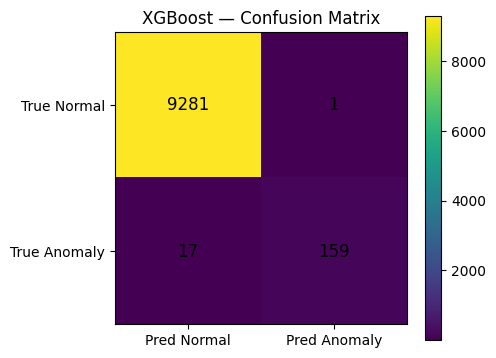

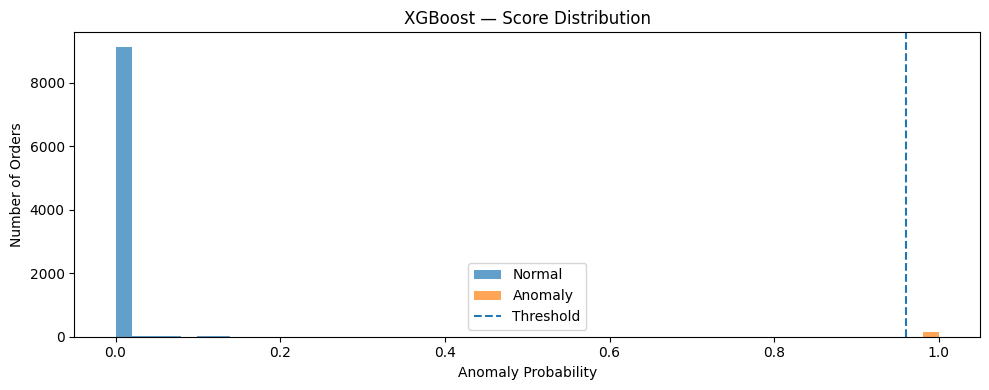

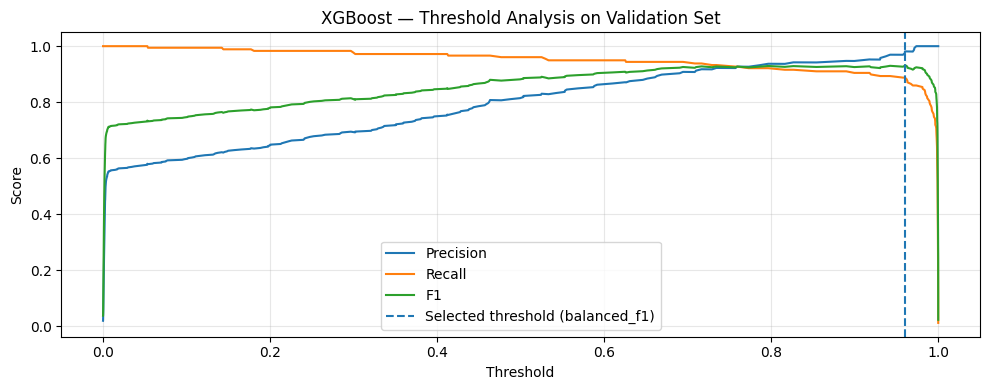

Top alerts for: XGBoost


,order_id,is_anomaly,anomaly_type,cashier_id,total_amount,anomaly_score,predicted_is_anomaly
55703,155664,1,basket_size_outlier,C07,146.50,0.999995,1
59435,159341,1,basket_size_outlier,C05,249.50,0.999994,1
54725,154628,1,basket_size_outlier,C10,138.44,0.999993,1
61006,160941,1,basket_size_outlier,C05,265.35,0.999993,1
56801,156712,1,basket_size_outlier,C03,77.01,0.999992,1
56766,156662,1,basket_size_outlier,C09,104.78,0.999992,1
61813,161690,1,basket_size_outlier,C09,90.82,0.999990,1
61886,161778,1,suspicious_discount,C07,1.65,0.999990,1
61212,161104,1,suspicious_discount,C07,4.62,0.999989,1
60056,159966,1,basket_size_outlier,C03,66.96,0.999988,1


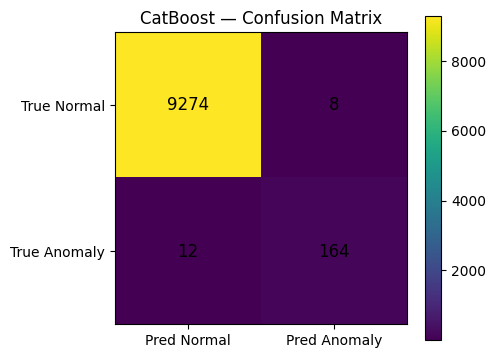

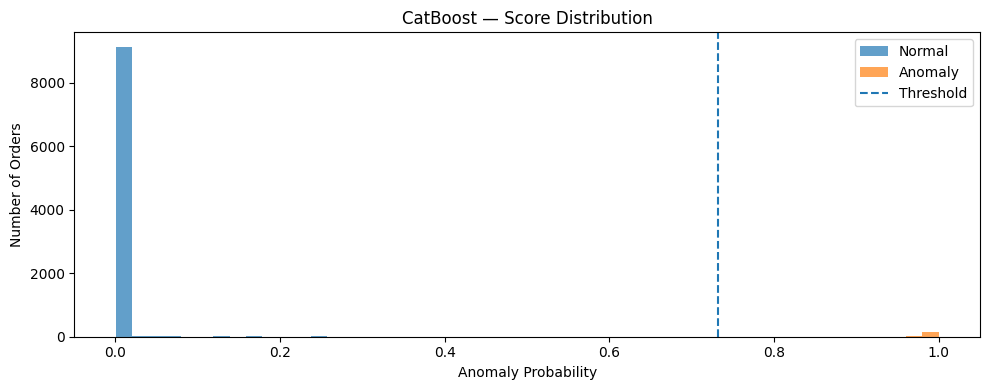

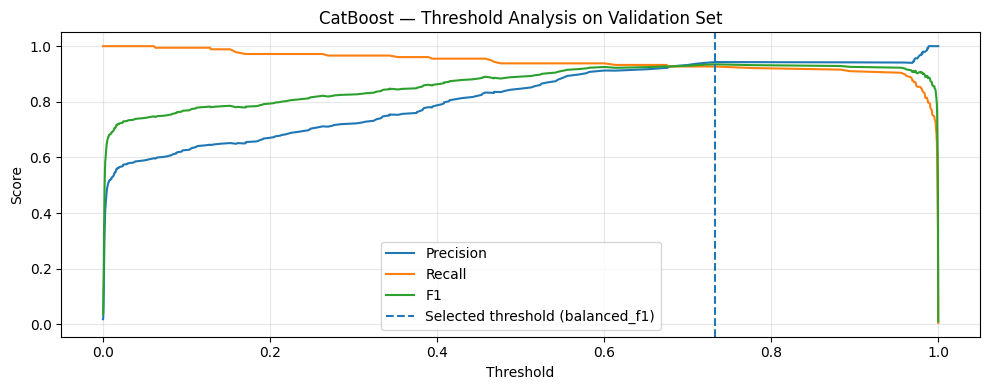

Top alerts for: CatBoost


,order_id,is_anomaly,anomaly_type,cashier_id,total_amount,anomaly_score,predicted_is_anomaly
61006,160941,1,basket_size_outlier,C05,265.35,0.999985,1
54725,154628,1,basket_size_outlier,C10,138.44,0.999972,1
56766,156662,1,basket_size_outlier,C09,104.78,0.999972,1
62816,162684,1,basket_size_outlier,C12,84.78,0.999959,1
57526,157448,1,basket_size_outlier,C10,109.46,0.999951,1
61886,161778,1,suspicious_discount,C07,1.65,0.999950,1
60314,160212,1,basket_size_outlier,C09,138.81,0.999950,1
61813,161690,1,basket_size_outlier,C09,90.82,0.999941,1
59435,159341,1,basket_size_outlier,C05,249.50,0.999940,1
61212,161104,1,suspicious_discount,C07,4.62,0.999915,1


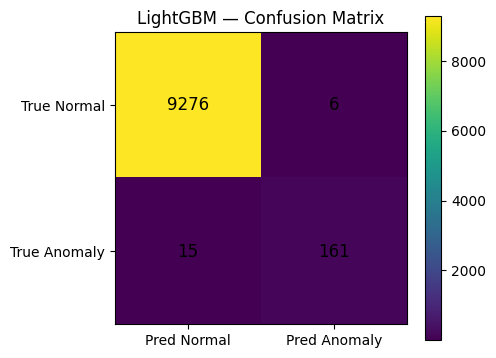

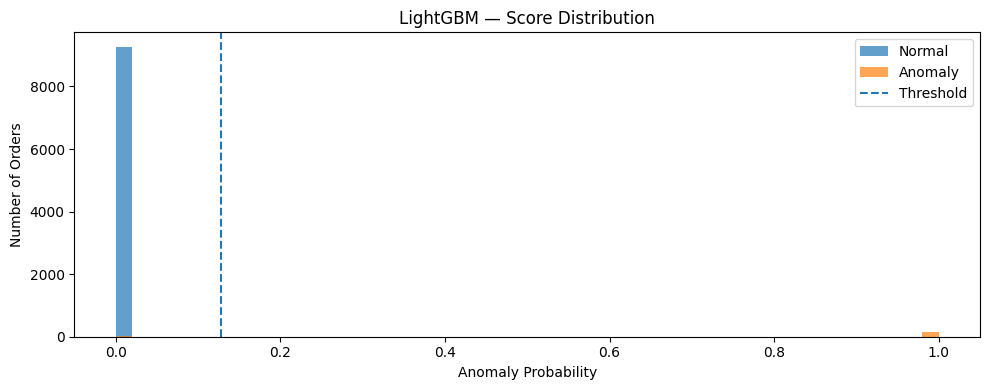

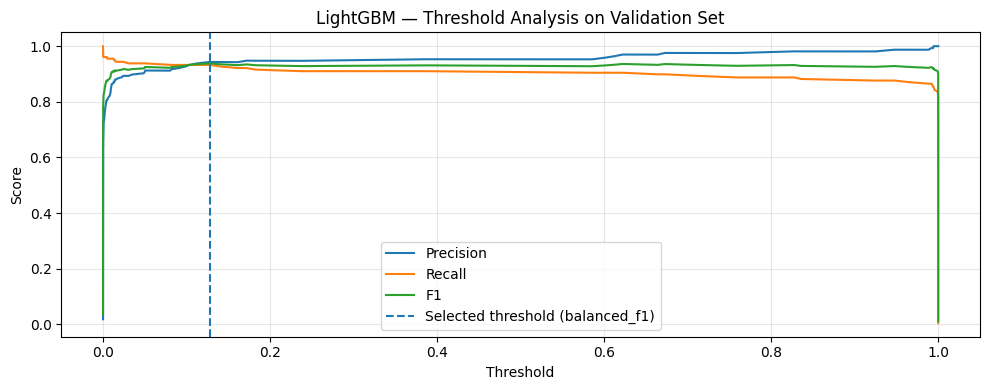

Top alerts for: LightGBM


,order_id,is_anomaly,anomaly_type,cashier_id,total_amount,anomaly_score,predicted_is_anomaly
61886,161778,1,suspicious_discount,C07,1.65,1.0,1
61212,161104,1,suspicious_discount,C07,4.62,1.0,1
54141,154041,1,suspicious_discount,C07,7.10,1.0,1
60113,159996,1,suspicious_discount,C07,11.10,1.0,1
59435,159341,1,basket_size_outlier,C05,249.50,1.0,1
58925,158828,1,odd_hour,C07,20.50,1.0,1
58929,158853,1,basket_size_outlier,C02,67.91,1.0,1
56801,156712,1,basket_size_outlier,C03,77.01,1.0,1
54943,154876,1,suspicious_discount,C07,2.00,1.0,1
61006,160941,1,basket_size_outlier,C05,265.35,1.0,1


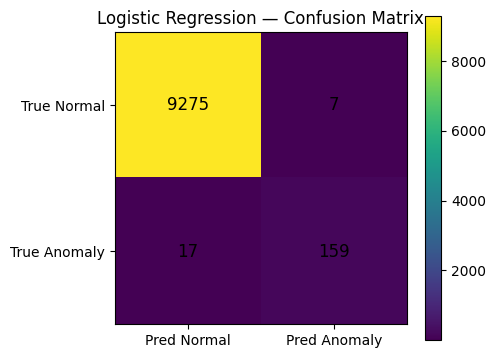

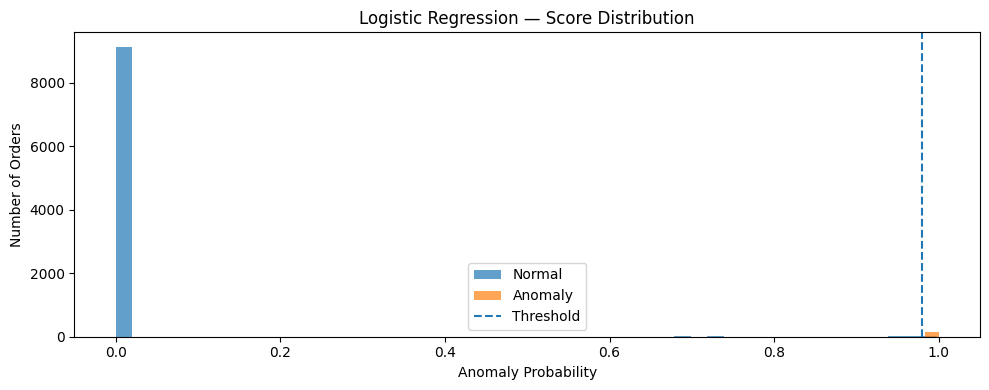

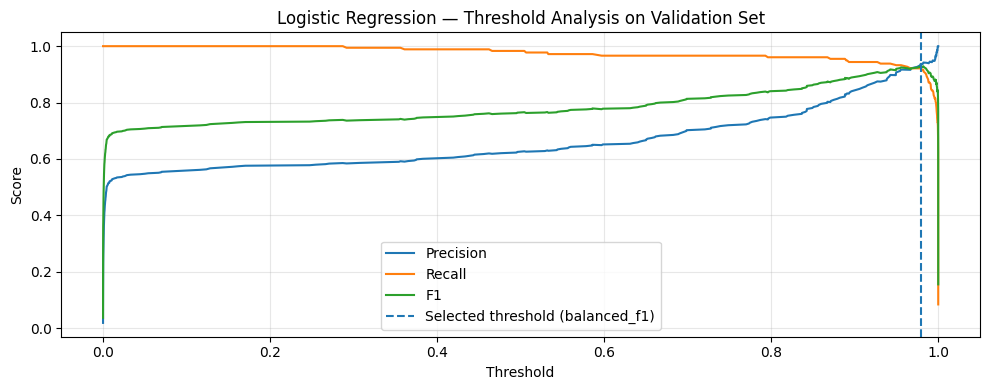

Top alerts for: Logistic Regression


,order_id,is_anomaly,anomaly_type,cashier_id,total_amount,anomaly_score,predicted_is_anomaly
58929,158853,1,basket_size_outlier,C02,67.91,1.0,1
55703,155664,1,basket_size_outlier,C07,146.50,1.0,1
54725,154628,1,basket_size_outlier,C10,138.44,1.0,1
61006,160941,1,basket_size_outlier,C05,265.35,1.0,1
53981,153924,1,price_tampering,C10,4.14,1.0,1
56730,156645,1,price_tampering,C04,5.00,1.0,1
57526,157448,1,basket_size_outlier,C10,109.46,1.0,1
62189,162122,1,price_tampering,C08,9.40,1.0,1
59044,158949,1,price_tampering,C11,3.94,1.0,1
58183,158111,1,price_tampering,C02,12.51,1.0,1


In [12]:
def safe_filename(name):
    return name.replace(' ', '_').replace('/', '_').lower()


def plot_confusion_matrix_for_model(model_name):
    row = metrics_selected_df[metrics_selected_df['model'].eq(model_name)].iloc[0]
    threshold = row['threshold']
    scores = scores_test[model_name]
    pred = (scores >= threshold).astype(int)
    cm = confusion_matrix(y_test, pred, labels=[0, 1])
    plt.figure(figsize=(5, 4))
    plt.imshow(cm)
    plt.title(f'{model_name} — Confusion Matrix')
    plt.xticks([0, 1], ['Pred Normal', 'Pred Anomaly'])
    plt.yticks([0, 1], ['True Normal', 'True Anomaly'])
    for i in range(2):
        for j in range(2):
            plt.text(j, i, cm[i, j], ha='center', va='center', fontsize=12)
    plt.colorbar()
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / f"confusion_matrix_{safe_filename(model_name)}.png", dpi=150, bbox_inches='tight')
    plt.show()


def plot_score_distribution_for_model(model_name):
    row = metrics_selected_df[metrics_selected_df['model'].eq(model_name)].iloc[0]
    threshold = row['threshold']
    scores = scores_test[model_name]
    plt.figure(figsize=(10, 4))
    plt.hist(scores[y_test == 0], bins=50, alpha=0.7, label='Normal')
    plt.hist(scores[y_test == 1], bins=50, alpha=0.7, label='Anomaly')
    plt.axvline(threshold, linestyle='--', label='Threshold')
    plt.title(f'{model_name} — Score Distribution')
    plt.xlabel('Anomaly Probability')
    plt.ylabel('Number of Orders')
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / f"score_distribution_{safe_filename(model_name)}.png", dpi=150, bbox_inches='tight')
    plt.show()


def plot_threshold_analysis_for_model(model_name):
    curve = curves[model_name].copy()
    row = metrics_selected_df[metrics_selected_df['model'].eq(model_name)].iloc[0]
    threshold = row['threshold']
    plt.figure(figsize=(10, 4))
    plt.plot(curve['threshold'], curve['precision'], label='Precision')
    plt.plot(curve['threshold'], curve['recall'], label='Recall')
    plt.plot(curve['threshold'], curve['f1'], label='F1')
    plt.axvline(threshold, linestyle='--', label=f'Selected threshold ({SELECTED_MODE})')
    plt.title(f'{model_name} — Threshold Analysis on Validation Set')
    plt.xlabel('Threshold')
    plt.ylabel('Score')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / f"threshold_analysis_{safe_filename(model_name)}.png", dpi=150, bbox_inches='tight')
    plt.show()


def show_top_alerts(model_name, n=10):
    row = metrics_selected_df[metrics_selected_df['model'].eq(model_name)].iloc[0]
    threshold = row['threshold']
    scores = scores_test[model_name]
    pred = (scores >= threshold).astype(int)
    cols = [c for c in ['order_id', 'is_anomaly', 'anomaly_type', 'cashier_id', 'total_amount'] if c in test_df.columns]
    alerts = test_df[cols].copy()
    alerts['anomaly_score'] = scores
    alerts['predicted_is_anomaly'] = pred
    alerts = alerts.sort_values('anomaly_score', ascending=False).head(n)
    print(f'Top alerts for: {model_name}')
    display(alerts)

for model_name in metrics_selected_df['model'].tolist():
    plot_confusion_matrix_for_model(model_name)
    plot_score_distribution_for_model(model_name)
    plot_threshold_analysis_for_model(model_name)
    show_top_alerts(model_name, n=10)

## 11. Per-anomaly-type recall

In [13]:
per_type_rows = []
for model_name in metrics_selected_df['model'].tolist():
    threshold = metrics_selected_df[metrics_selected_df['model'].eq(model_name)].iloc[0]['threshold']
    scores = scores_test[model_name]
    pred = (scores >= threshold).astype(int)
    tmp = test_df[['order_id', 'anomaly_type', 'is_anomaly']].copy()
    tmp['predicted_is_anomaly'] = pred
    for anomaly_type in sorted(tmp[tmp['is_anomaly'].eq(1)]['anomaly_type'].unique()):
        subset = tmp[tmp['anomaly_type'].eq(anomaly_type)]
        recall_type = subset['predicted_is_anomaly'].mean() if len(subset) else np.nan
        per_type_rows.append({'model': model_name, 'anomaly_type': anomaly_type, 'n_cases': int(len(subset)), 'recall': float(recall_type)})

per_type_df = pd.DataFrame(per_type_rows)
per_type_path = METRIC_DIR / 'supervised_per_anomaly_type_recall.csv'
per_type_df.to_csv(per_type_path, index=False)
print('Saved per-type recall to:', per_type_path)
display(per_type_df.pivot(index='anomaly_type', columns='model', values='recall').round(3))

Saved per-type recall to: ..\Supervised\metrics\supervised_per_anomaly_type_recall.csv


model,CatBoost,Extra Trees,HistGradientBoosting,LightGBM,Logistic Regression,Random Forest,XGBoost
anomaly_type,,,,,,,
basket_size_outlier,1.000,1.000,1.000,1.000,1.000,1.000,1.0
odd_hour,0.969,0.969,0.969,1.000,1.000,1.000,1.0
price_tampering,1.000,1.000,1.000,1.000,1.000,1.000,1.0
shift_end_void_cluster,1.000,1.000,1.000,1.000,0.867,1.000,1.0
suspicious_discount,1.000,1.000,0.974,1.000,0.974,1.000,1.0
void_after_payment,0.676,0.676,0.647,0.559,0.588,0.676,0.5


## 12. Feature importance for tree-based models

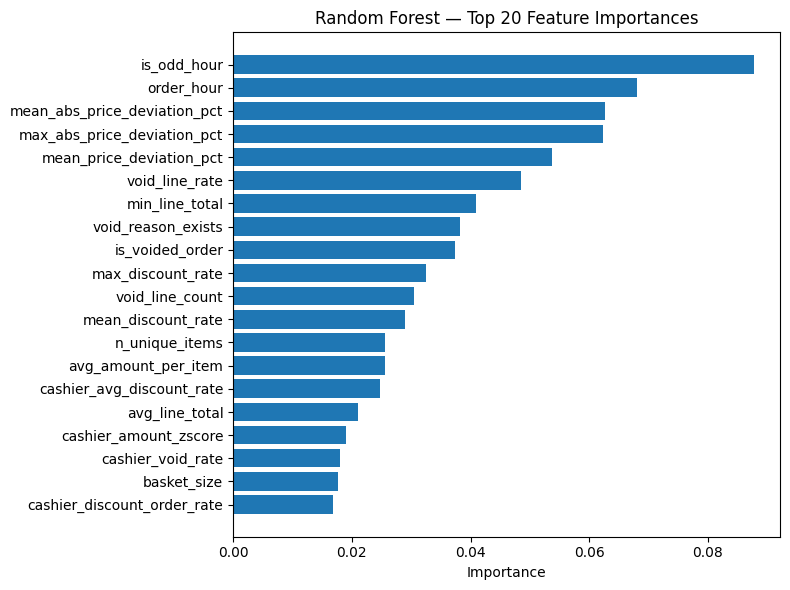

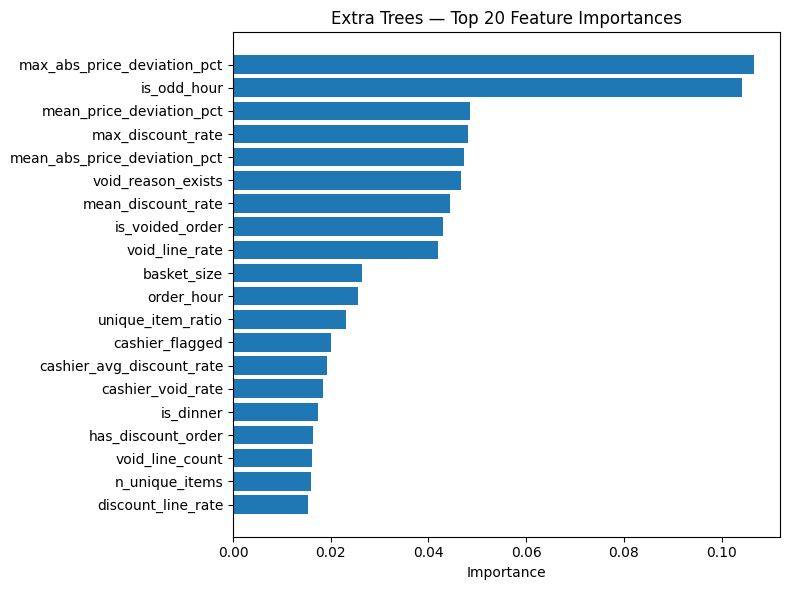

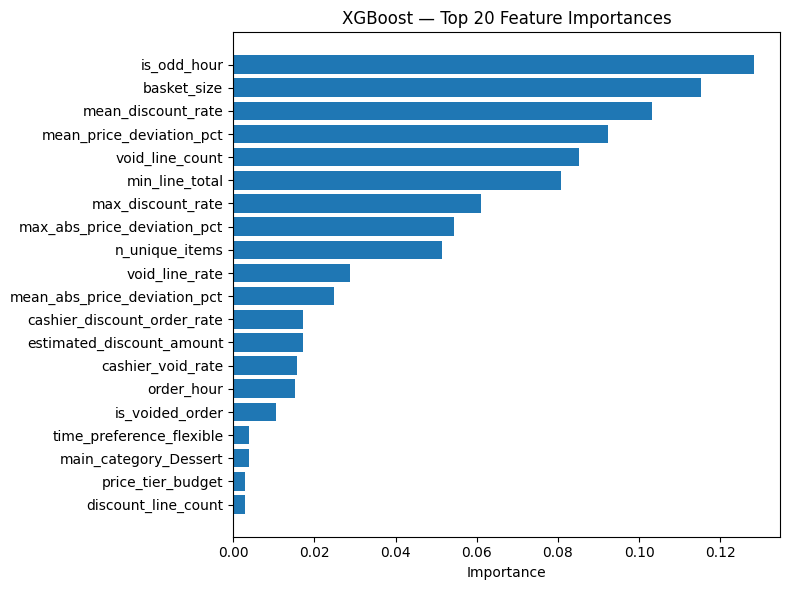

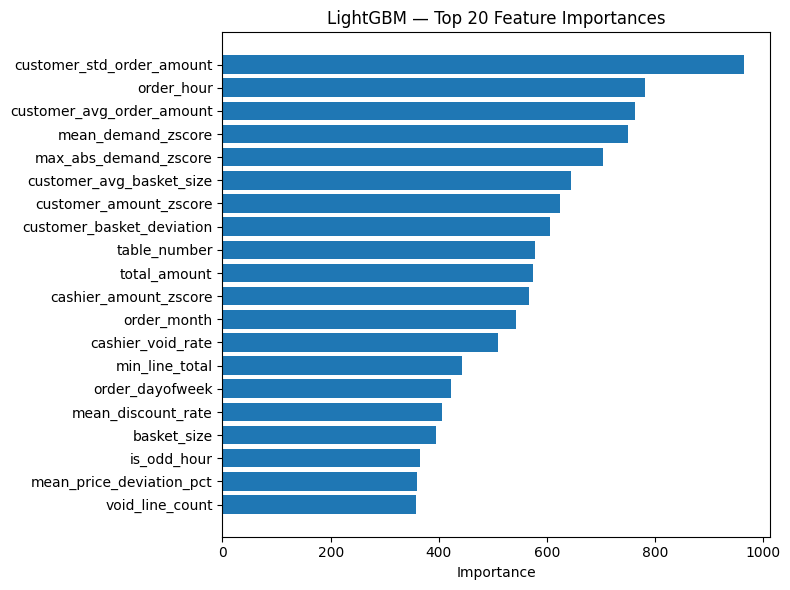

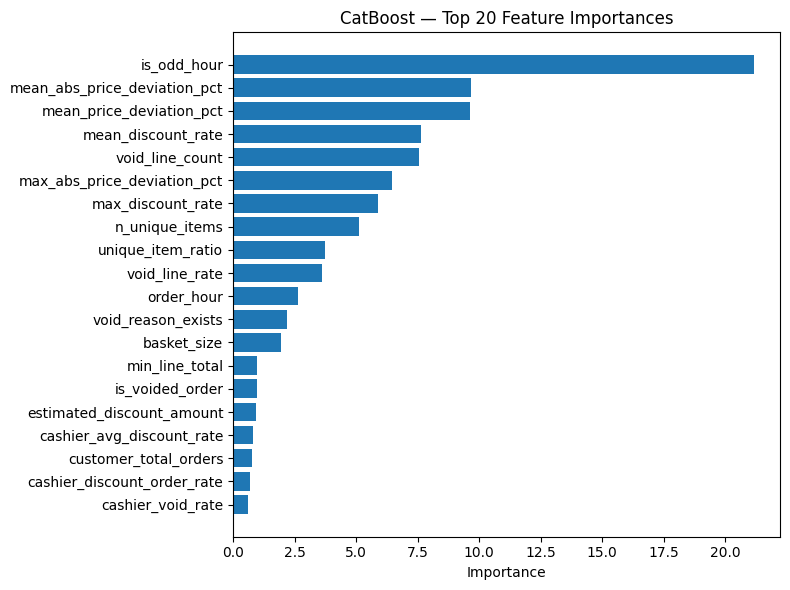

Saved feature importances to: ..\Supervised\metrics\supervised_feature_importance.csv


,model,feature,importance
0,Random Forest,is_odd_hour,0.087758
1,Random Forest,order_hour,0.067973
2,Random Forest,mean_abs_price_deviation_pct,0.062580
3,Random Forest,max_abs_price_deviation_pct,0.062401
4,Random Forest,mean_price_deviation_pct,0.053774
5,Random Forest,void_line_rate,0.048486
6,Random Forest,min_line_total,0.040988
7,Random Forest,void_reason_exists,0.038231
8,Random Forest,is_voided_order,0.037365
9,Random Forest,max_discount_rate,0.032490


In [14]:
def get_feature_names(preprocessor):
    names = []
    names.extend(numeric_features + binary_features)
    try:
        cat_encoder = preprocessor.named_transformers_['cat'].named_steps['onehot']
        names.extend(cat_encoder.get_feature_names_out(categorical_features).tolist())
    except Exception:
        pass
    return np.array(names)

feature_names = get_feature_names(preprocessor)
importance_rows = []

for name, model in trained_models.items():
    if hasattr(model, 'feature_importances_'):
        importances = np.asarray(model.feature_importances_)
        n = min(len(feature_names), len(importances))
        imp_df = pd.DataFrame({'model': name, 'feature': feature_names[:n], 'importance': importances[:n]}).sort_values('importance', ascending=False)
        importance_rows.append(imp_df)
        top_imp = imp_df.head(20)
        plt.figure(figsize=(8, 6))
        plt.barh(top_imp['feature'][::-1], top_imp['importance'][::-1])
        plt.title(f'{name} — Top 20 Feature Importances')
        plt.xlabel('Importance')
        plt.tight_layout()
        plt.savefig(FIGURE_DIR / f"feature_importance_{safe_filename(name)}.png", dpi=150, bbox_inches='tight')
        plt.show()

if importance_rows:
    feature_importance_df = pd.concat(importance_rows, ignore_index=True)
    feature_importance_path = METRIC_DIR / 'supervised_feature_importance.csv'
    feature_importance_df.to_csv(feature_importance_path, index=False)
    print('Saved feature importances to:', feature_importance_path)
    display(feature_importance_df.groupby('model').head(10))
else:
    print('No native feature importance available for the trained models.')

## 13. Save predictions, models, metadata, and completion report

In [15]:
prediction_frames = []
for model_name in metrics_selected_df['model'].tolist():
    threshold = metrics_selected_df[metrics_selected_df['model'].eq(model_name)].iloc[0]['threshold']
    scores = scores_test[model_name]
    pred = (scores >= threshold).astype(int)
    cols = [c for c in ['order_id', 'order_datetime', 'cashier_id', 'customer_id', 'total_amount', 'anomaly_type', 'is_anomaly'] if c in test_df.columns]
    tmp = test_df[cols].copy()
    tmp['model'] = model_name
    tmp['threshold_mode'] = SELECTED_MODE
    tmp['threshold'] = threshold
    tmp['anomaly_score'] = scores
    tmp['predicted_is_anomaly'] = pred
    prediction_frames.append(tmp)

predictions_df = pd.concat(prediction_frames, ignore_index=True)
predictions_path = PREDICTION_DIR / 'supervised_predictions.csv'
predictions_df.to_csv(predictions_path, index=False)

best_row = metrics_selected_df.iloc[0]
best_model_name = best_row['model']
best_model = trained_models[best_model_name]

with open(MODEL_DIR / 'supervised_preprocessor.pkl', 'wb') as f:
    pickle.dump(preprocessor, f)
with open(MODEL_DIR / 'best_supervised_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)
with open(MODEL_DIR / 'trained_supervised_models.pkl', 'wb') as f:
    pickle.dump(trained_models, f)

metadata = {
    'notebook': '03_supervised_anomaly_models_FINAL',
    'selected_threshold_mode': SELECTED_MODE,
    'required_models': REQUIRED_MODELS,
    'trained_models': list(trained_models.keys()),
    'best_supervised_model': best_model_name,
    'best_threshold': float(best_row['threshold']),
    'best_precision': float(best_row['precision']),
    'best_recall': float(best_row['recall']),
    'best_f1': float(best_row['f1']),
    'best_pr_auc': float(best_row['pr_auc']),
    'model_features': model_features,
    'numeric_features': numeric_features,
    'binary_features': binary_features,
    'categorical_features': categorical_features,
}

with open(MODEL_DIR / 'supervised_model_metadata.json', 'w', encoding='utf-8') as f:
    json.dump(metadata, f, indent=2)

completion = pd.DataFrame([{
    'status': 'completed',
    'n_required_models': len(REQUIRED_MODELS),
    'n_trained_models': len(trained_models),
    'best_model': best_model_name,
    'best_precision': float(best_row['precision']),
    'best_recall': float(best_row['recall']),
    'best_f1': float(best_row['f1']),
    'best_pr_auc': float(best_row['pr_auc']),
}])
completion_path = REPORT_DIR / 'supervised_completion_summary.csv'
completion.to_csv(completion_path, index=False)

assert set(REQUIRED_MODELS) == set(trained_models.keys()), 'Not all required models were trained.'
assert metrics_selected_df['model'].nunique() == len(REQUIRED_MODELS), 'Selected metrics missing one or more models.'

print('Saved predictions to:', predictions_path)
print('Saved models to:', MODEL_DIR)
print('Saved completion summary to:', completion_path)
print('Best supervised candidate:', best_model_name)
display(completion)
display(pd.DataFrame([metadata]).T.rename(columns={0: 'value'}))

Saved predictions to: ..\Supervised\predictions\supervised_predictions.csv
Saved models to: ..\Supervised\models
Saved completion summary to: ..\Supervised\reports\supervised_completion_summary.csv
Best supervised candidate: Random Forest


,status,n_required_models,n_trained_models,best_model,best_precision,best_recall,best_f1,best_pr_auc
0,completed,7,7,Random Forest,0.964912,0.9375,0.951009,0.976973


,value
notebook,03_supervised_anomaly_models_FINAL
selected_threshold_mode,balanced_f1
required_models,"[Logistic Regression, Random Forest, Extra Tre..."
trained_models,"[Logistic Regression, Random Forest, Extra Tre..."
best_supervised_model,Random Forest
best_threshold,0.254509
best_precision,0.964912
best_recall,0.9375
best_f1,0.951009
best_pr_auc,0.976973


## 14. Overfitting and Leakage Check

In [17]:
# Overfitting check: Train / Validation / Test comparison
# This version recomputes the balanced_f1 threshold from validation scores.

import numpy as np
import pandas as pd
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    average_precision_score, roc_auc_score,
    precision_recall_curve
)

def find_best_f1_threshold(y_true, scores):
    precision, recall, thresholds = precision_recall_curve(y_true, scores)
    f1_scores = 2 * precision[:-1] * recall[:-1] / (precision[:-1] + recall[:-1] + 1e-9)
    best_idx = np.argmax(f1_scores)
    return thresholds[best_idx]

def evaluate_split(name, y_true, y_score, threshold):
    y_pred = (y_score >= threshold).astype(int)
    return {
        "split": name,
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "pr_auc": average_precision_score(y_true, y_score),
        "roc_auc": roc_auc_score(y_true, y_score),
        "false_alerts": int(((y_true == 0) & (y_pred == 1)).sum()),
        "missed_anomalies": int(((y_true == 1) & (y_pred == 0)).sum())
    }

best_model_name = "Random Forest"
best_model = trained_models[best_model_name]

train_scores = best_model.predict_proba(X_train_processed)[:, 1]
val_scores = best_model.predict_proba(X_val_processed)[:, 1]
test_scores = best_model.predict_proba(X_test_processed)[:, 1]

best_threshold = find_best_f1_threshold(y_val.values, val_scores)

print("Best model:", best_model_name)
print("Validation-selected threshold:", round(best_threshold, 4))

overfit_check = pd.DataFrame([
    evaluate_split("train", y_train.values, train_scores, best_threshold),
    evaluate_split("validation", y_val.values, val_scores, best_threshold),
    evaluate_split("test", y_test.values, test_scores, best_threshold),
])

overfit_check

NameError: name 'X_train_processed' is not defined

In [ ]:
# Check for dangerous leakage columns

dangerous_keywords = [
    "is_anomaly",
    "anomaly_type",
    "label",
    "target",
    "ground_truth",
    "future",
    "test",
    "split"
]

leakage_suspects = [
    col for col in feature_cols
    if any(keyword in col.lower() for keyword in dangerous_keywords)
]

print("Potential leakage columns:")
print(leakage_suspects)

## 15. Notebook conclusion

This notebook trained all required supervised anomaly detection models and saved the final metrics, plots, predictions, and artifacts.

The next notebook will compare the best supervised model with the best unsupervised model and select the final anomaly detection approach for deployment.